**Tutorial for PARAFAC2-RISE on scRNA-seq Data Measured Across Multiple Conditions**

This tutorial demonstrates how to use PARAFAC2-RISE (Reduction and Insight in Single-cell Exploration) to analyze single-cell RNA sequencing (scRNA-seq) data across multiple experimental conditions. 

**Step 1: Import and Prepare the Dataset**

First, import your dataset as an AnnData object. The dataset must include a column *condition_unique_idx* that is 0-indexed and uniquely identifies each experimental condition. Condition 1 cells indexed as 0, Condition 2 as 1, and so on. Ensure the data is preprocessed (e.g., doublets removed, genes filtered, normalized, and log-transformed). The *prepare_dataset* function from *parafac2.normalize* can assist with preprocessing including assigning *condition_unique_idx* and gene filtering, and *doubletdetection* can help remove doublets.

In [1]:
from RISE.imports import import_thomson

X = import_thomson()
print(X)

/home/aramirez/RISE/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/aramirez/RISE/.venv/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 29433 × 9461
    obs: 'Condition', 'doublet', 'Cell Type', 'Cell Type2', 'condition_unique_idxs'
    var: 'gene_ids', 'feature_types', 'means'


**Step 2: Assess Variance Explained by RISE and PCA**

To determine the optimal component/rank for the RISE model, plot the variance explained (R²X) across different ranks for both RISE and PCA. This helps balance model complexity (higher ranks) with explanatory power. PCA serves as a baseline for comparison since it is a standard linear dimensionality reduction method.

100%|██████████| 7/7 [00:35<00:00,  5.07s/it]
/home/aramirez/RISE/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(


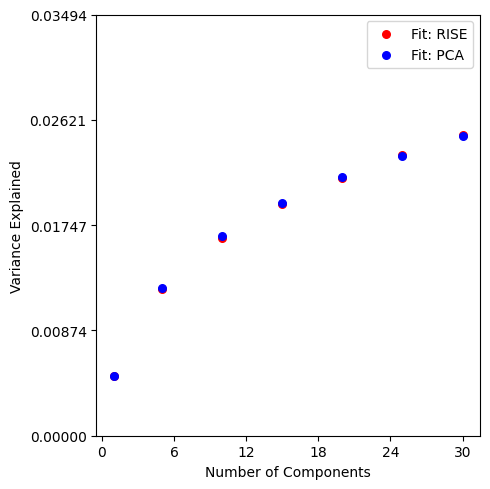

In [2]:
from RISE.figures.commonFuncs.plotGeneral import plot_r2x
%matplotlib inline
import matplotlib.pyplot as plt

ranks = [1, 5, 10, 15, 20, 25, 30]
fig, ax = plt.subplots(figsize=(5, 5))

plot_r2x(X, ranks, ax)
plt.tight_layout()
plt.show()

**Step 3: Evaluate Factor Stability with Factor Match Score (FMS)**

The Factor Match Score (FMS) measures the reproducibility of the RISE factorization across different ranks. THE FMS is calculated based on the factors of the original dataset and a bootstrapped version of the data. An FMS above ~0.6 indicates stable components.

/home/aramirez/RISE/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
 10%|▉         | 49/500 [00:06<00:59,  7.60it/s, R2X=0.0272, error=0.973, jump=5.13, Δ=-3.72e-6]


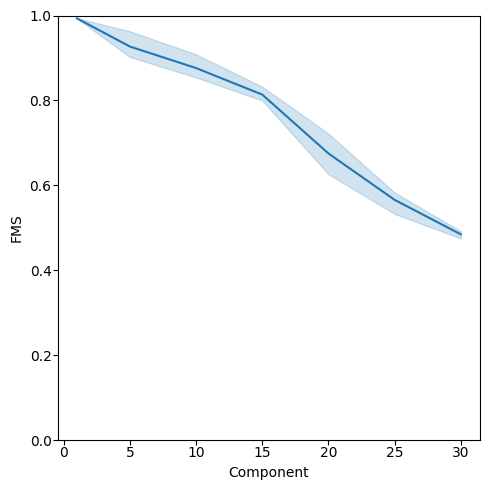

In [3]:
from RISE.figures.figureS4 import plot_fms_diff_ranks
%matplotlib inline

fig, ax = plt.subplots(figsize=(5, 5))

rank_list = list(ranks)

plot_fms_diff_ranks(X, ax, ranksList=rank_list, runs=3)
plt.tight_layout()
plt.show()

**Step 4: Perform RISE Factorization**

Based on the variance explained and FMS, select a rank (e.g., 20) and perform the RISE factorization. This decomposes the data into condition, eigenstate (cell), and gene factors, which can be interpreted to determine the important patterns in the dataset. We recommend using *doEmbedding* to visualize the cell-cell heterogeneity in a 2D embedding space.

In [11]:
from RISE.factorization import pf2

rank = 20
X = pf2(X=X, rank=rank, doEmbedding=True, tolerance=1e-9, max_iter=500, random_state=42)

 10%|▉         | 49/500 [00:05<00:50,  8.98it/s, R2X=0.0214, error=0.979, jump=5.13, Δ=-1.71e-6]
/home/aramirez/RISE/.venv/lib/python3.12/site-packages/pacmap/pacmap.py:822: UserWarning: Warning: random state is set to 42
  warnings.warn(f'Warning: random state is set to {_RANDOM_STATE}')


**Step 5: Visualize Condition Factor**

The condition factor show how each experimental condition contributes to the identified patterns. Log-transforming these factors allows for easier interpretation of condition-specific effects. *Condition* represents the experimental conditions column name.

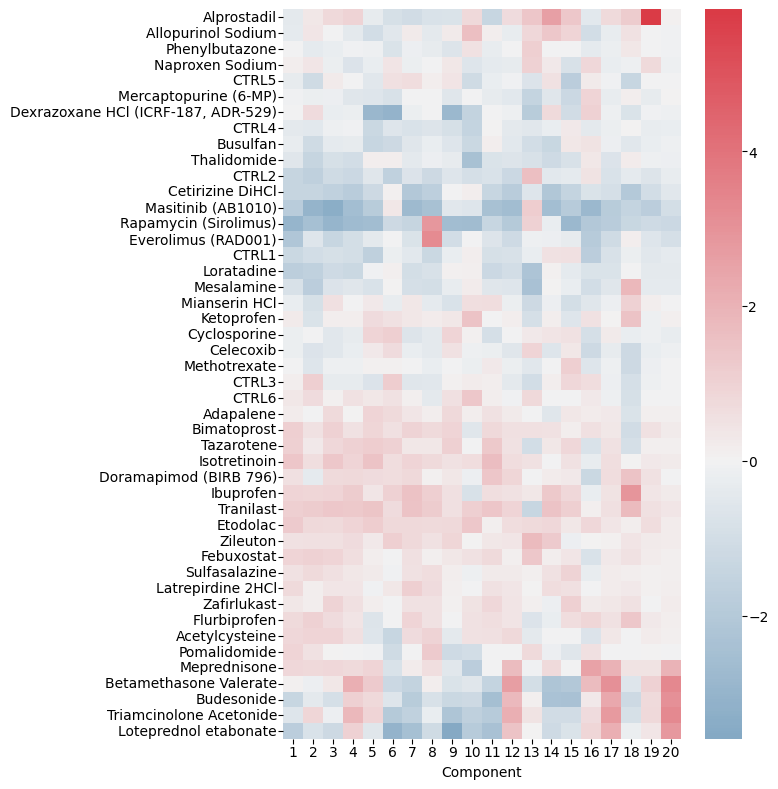

In [5]:
from RISE.figures.commonFuncs.plotFactors import plot_condition_factors
%matplotlib inline

fig, ax = plt.subplots(figsize=(8, 8))

plot_condition_factors(X, ax=ax, cond="Condition", log_transform=True)
plt.tight_layout()
plt.show()

**Step 6: Visualize Cell Embedding**

The projection-based cell embedding represents the latent space of the cells in the dataset and can be represented by nonlinear data reduction methods such as PaCMAP. You can label this embedding with cell type annotations to visualize how different cell types cluster in the latent space, such as by *Cell Type*, or by their experimental condition, such as *Condition*.

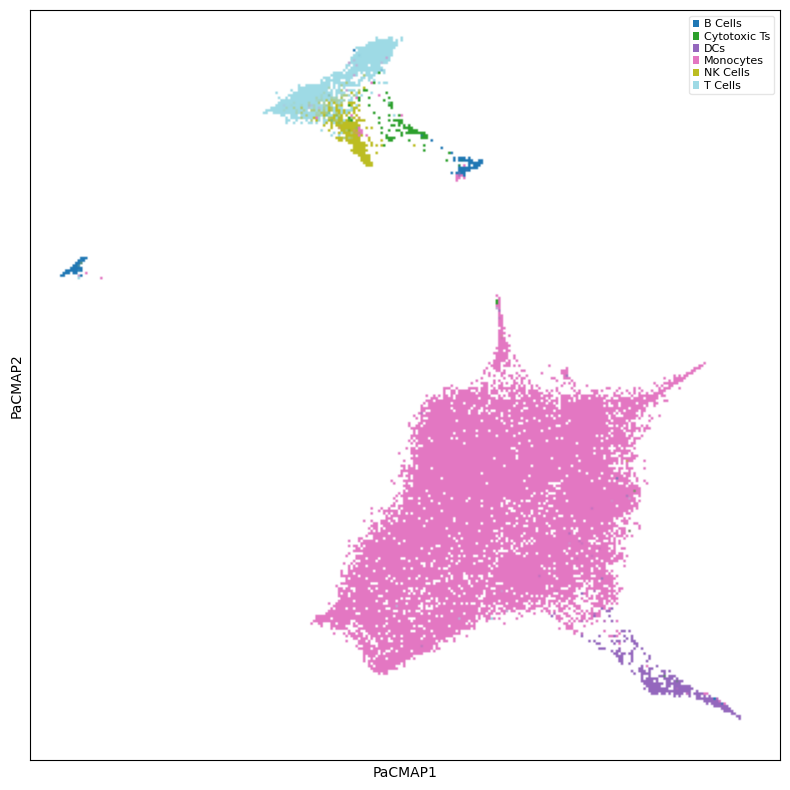

In [12]:
from RISE.figures.commonFuncs.plotPaCMAP import plot_labels_pacmap
%matplotlib inline

fig, ax = plt.subplots(figsize=(8, 8))

plot_labels_pacmap(X, labelType="Cell Type", ax=ax)
plt.tight_layout()
plt.show()

**Step 7: Visualize Eigen-State Factor**

The cell states or eigen-states represent how each cell contributes to the identified patterns. Each eigen-state represents a summary of similar cells with a distinct expression profile. **Step 10** shows how to visualize which cells are relevant for the eigen-states highly weighted for a specific component.

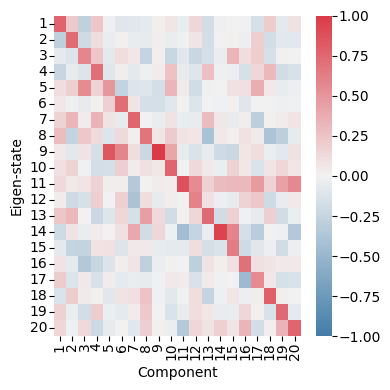

In [7]:
from RISE.figures.commonFuncs.plotFactors import plot_eigenstate_factors
%matplotlib inline
fig, ax = plt.subplots(figsize=(4, 4))

plot_eigenstate_factors(X, ax=ax)
plt.ylabel("Eigen-state")
plt.tight_layout()
plt.show()

**Step 8: Visualize Gene Factor**

The gene factor demonstrates which genes are highly weighted in each component, revealing coordinated gene modules. A weight value can be adjusted to trim less informative genes, focusing on those that contribute significantly to the identified patterns. Higher weight values will trim more genes.

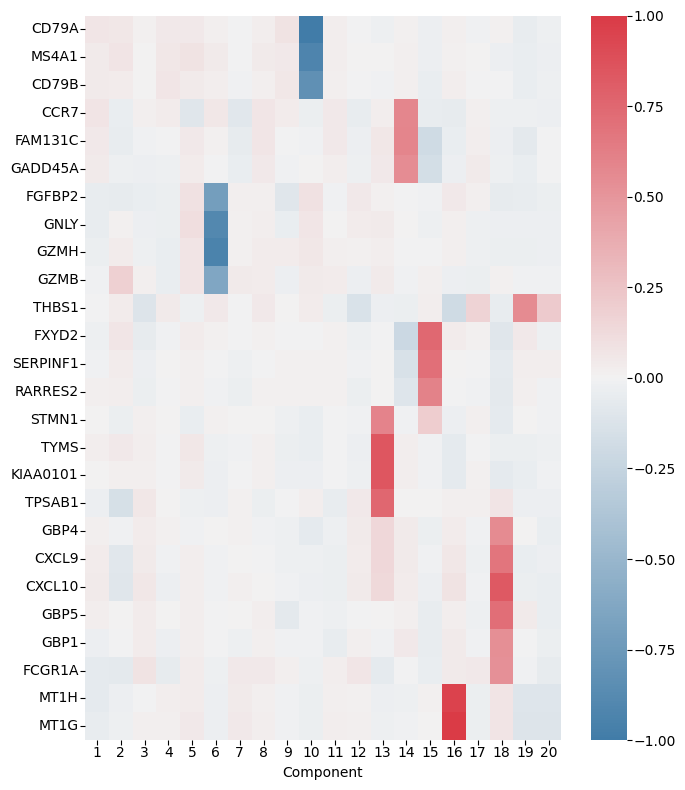

In [8]:
from RISE.figures.commonFuncs.plotFactors import plot_gene_factors
%matplotlib inline
fig, ax = plt.subplots(figsize=(7, 8))

plot_gene_factors(X, ax=ax, weight=0.2, trim=True)
plt.tight_layout()
plt.show()

**Step 9: Investigate Gene Associations for a Component**

Based on the gene weightings for a component (e.g. component 10), we can overlay the gene expression (e.g., MS4A1) on the cell embedding to see which cells express it. *clip_outliers* can be used to remove outlier cells for easier visual interpretation.

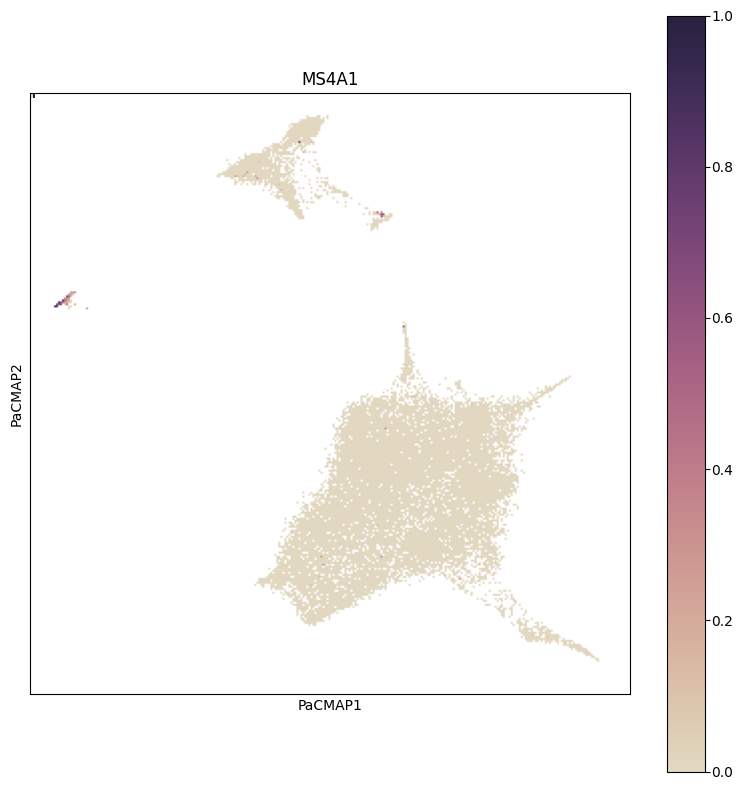

In [13]:
from RISE.figures.commonFuncs.plotPaCMAP import plot_gene_pacmap

fig, ax = plt.subplots(figsize=(8, 8))

gene = "MS4A1" 
plot_gene_pacmap(gene, X, ax=ax, clip_outliers=0.9995)
plt.tight_layout()
plt.show()

**Step 10: Investigate Cell Associations for a Component**

The weighted projections for a component (e.g. component 10) visualize how cells contribute to that specific component, revealing subpopulations with distinct expression patterns. The weighted projections could also be plotted broken down by cell type or cluster for more detailed analysis. cbarMax can be reduced to better visualize the most relevant cells.

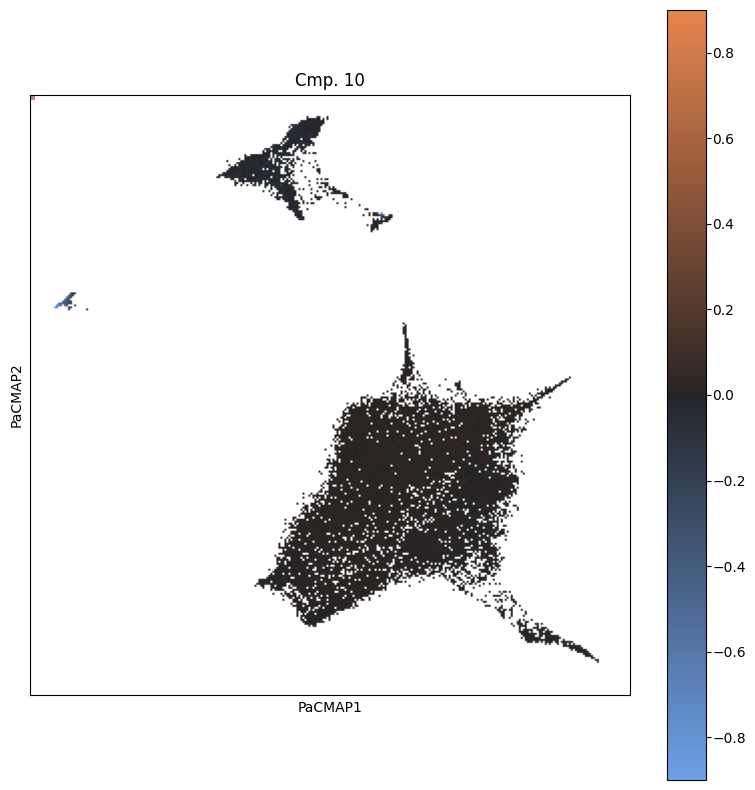

In [14]:
from RISE.figures.commonFuncs.plotPaCMAP import plot_wp_pacmap

fig, ax = plt.subplots(figsize=(8, 8))

plot_wp_pacmap(X, cmp=10, ax=ax, cbarMax=0.9)
plt.tight_layout()
plt.show()